# Part 3 - Understanding the EEG file

Parts 1 and 2 were about fMRI: the thing we want to **predict**.

This part is about EEG: the thing we predict **from**. It is a completely different kind of
measurement, stored in a completely different kind of file, and the differences matter.

**Goal of this part:** open one EEG recording, understand its format, and look at a real brain
wave. No spectrograms yet - that is Part 4.

---

### The one-sentence version

An EEG file is **64 voltage meters taped to a scalp, each writing down a number 250 times a
second, for 13 minutes.**

---

### How EEG and fMRI differ

Worth fixing in your head before you open anything, because almost every design decision in this
project follows from this table:

| | fMRI (Parts 1-2) | EEG (this part) |
|---|---|---|
| measures | blood oxygen | electrical voltage |
| how direct | an indirect after-effect | the actual neural signal |
| speed | 1 sample every 2.16 s | 250 samples every second |
| delay | lags the cause by ~5 s | essentially instant |
| where | everywhere in the 3D brain | only the outside of the scalp |
| numbers per second | 56,889 | 16,000 |

Notice the trade. EEG is fast and direct but only sees the surface. fMRI is slow and indirect but
sees everywhere. Neither one is better; they are blind in different directions.

---

### How to run this notebook

Click the first code cell, press **Shift + Enter**, and keep going. If a cell errors, stop and
read it rather than pressing on.

## Step 1 - Install and import

One new package compared to Part 1: **MNE**. It is the standard Python library for EEG, and it
knows how to read the BrainVision format our files are in.

In [21]:
# Run once. -q keeps the output quiet.
%pip install -q mne numpy matplotlib
%pip install mne

Note: you may need to restart the kernel to use updated packages.



In [22]:
import numpy as np                # grids of numbers
import matplotlib.pyplot as plt   # drawing
import mne                        # the EEG library
from pathlib import Path          # file paths

# MNE prints a lot of chatty progress messages by default.
# "ERROR" means: only speak up if something is actually wrong.
mne.set_log_level("ERROR")

plt.rcParams["figure.dpi"] = 110

print("MNE version:", mne.__version__)

MNE version: 1.12.1


## Step 2 - One recording is three files, not one

This trips up almost everyone the first time. A single BrainVision EEG recording is stored as
**three separate files that must sit together in the same folder**:

| extension | contains | size |
|---|---|---|
| `.vhdr` | the **header**. Plain text. Describes the recording and names the other two files. | a few KB |
| `.vmrk` | the **markers**. Plain text. Timestamps of events, like "a scanner volume started here". | a few hundred KB |
| `.dat` or `.eeg` | the **data**. Binary. The actual voltage numbers. | 40 to 500 MB |

You always open the `.vhdr`. MNE reads it, finds the names of the other two inside it, and loads
them. If any of the three is missing or renamed, it fails.

Let's find them.

In [23]:
DATA_FOLDER = Path(r"E:\EEG_to_FMRI")

# Search everywhere under the data folder for header files.
all_vhdr = sorted(DATA_FOLDER.rglob("*.vhdr"))
print(f"Raw search found {len(all_vhdr)} .vhdr files")

# The zip archives came from a Mac, which left behind "__MACOSX" folders full of
# fake companion files whose names start with "._". They are not real data.
# str(p) turns the Path into text so we can search inside it.
real_vhdr = [p for p in all_vhdr
             if not p.name.startswith("._")          # drop Mac companion files
             and "__MACOSX" not in str(p)]           # drop the whole junk folder

print(f"After removing Mac junk : {len(real_vhdr)} real .vhdr files")
print()
print("Notice it is 2 per subject, not 1. The next step explains why.")

Raw search found 64 .vhdr files
After removing Mac junk : 32 real .vhdr files

Notice it is 2 per subject, not 1. The next step explains why.


## Step 3 - `export/` versus `raw/`, and why only one is usable

Each subject folder has two sub-folders, each with a complete recording:

```
EEG/<subject>/
  |-- raw/      the original recording straight off the amplifier
  \-- export/   the cleaned version
```

**You must use `export/`.** Here is why, and it is worth understanding properly because it is the
single most important fact about EEG recorded inside an MRI scanner.

An MRI scanner works by switching enormous magnetic fields on and off very fast. EEG works by
measuring tiny voltages through wires taped to a head. But moving a wire through a changing
magnetic field **creates** voltage - that is how every electrical generator on earth works.

So the scanner induces voltage in the EEG wires. Real brain signal is around 10 to 100
microvolts. The scanner-induced signal is thousands of times larger. It is like trying to hear a
whisper while standing next to a jet engine.

That is the **gradient artifact**. There is a second, smaller one called the **BCG artifact**:
every heartbeat makes the scalp pulse slightly, and moving a wire inside a strong magnet again
creates voltage. The BCG artifact is nastier than the gradient artifact precisely because it is
*smaller* - it is about the same size as real brain signal, so it is much harder to separate out.

The `export/` folder holds the output after both corrections were applied in Brain Vision
Analyzer. The `raw/` folder is what it looked like before, and it is essentially unusable.

Let's split our list by which folder each file sits in.

In [24]:
# p.parent is the folder containing the file. .name gives just that folder's name.
export_files = [p for p in real_vhdr if p.parent.name == "export"]
raw_files    = [p for p in real_vhdr if p.parent.name == "raw"]

print(f"export/ headers : {len(export_files)}")
print(f"raw/    headers : {len(raw_files)}")
print()
print("Subjects found (from the folder two levels up):")
print()
for p in export_files:
    # p.parent is "export", p.parent.parent is the subject number folder.
    subject = p.parent.parent.name
    size_mb = p.stat().st_size / 1024
    print(f"  subject {subject:>3}   {p.name}")

export/ headers : 16
raw/    headers : 16

Subjects found (from the folder two levels up):

  subject  32   20130410320002_Segmentation_bin.vhdr
  subject  35   20130424350002_Pulse_Artifact_Correction_bin.vhdr
  subject  36   20130425360002_Pulse_Artifact_Correction_bin.vhdr
  subject  37   20130426370002_Pulse_Artifact_Correction_bin.vhdr
  subject  38   20130105380002_Pulse_Artifact_Correction_bin.vhdr
  subject  39   20130501390002_Pulse_Artifact_Correction_bin.vhdr
  subject  40   20130510400002_Pulse_Artifact_Correction_bin.vhdr
  subject  42   20130523420002_Pulse_Artifact_Correction_bin.vhdr
  subject  43   20130529430002_Pulse_Artifact_Correction_bin.vhdr
  subject  44   20130605440002_Pulse_Artifact_Correction_bin.vhdr
  subject  45   20130627450002_Pulse_Artifact_Correction_bin.vhdr
  subject  46   20130703460002_Pulse_Artifact_Correction_bin.vhdr
  subject  47   20130710470002_Pulse_Artifact_Correction_bin.vhdr
  subject  48   20130717480002_Pulse_Artifact_Correction_bin.vh

Two things to notice in that list.

**One subject is named differently.** Fifteen files are called
`..._Pulse_Artifact_Correction_bin.vhdr`. Subject 32's is called `..._Segmentation_bin.vhdr`.

The repo's loader does not care - it globs `export/*.vhdr` and only asserts there is exactly one.
So subject 32 loads fine. But the name is telling you something real: that subject's processing
chain stopped at segmentation and did **not** get the same pulse-artifact correction as the other
fifteen. It is a genuine inconsistency in the dataset, worth one sentence in your report rather
than a code change.

**The filenames encode a date.** `20130424350002` is 24 April 2013, subject 35. The recordings are
from 2013.

## Step 4 - Read the header yourself, as text

Here is something people rarely realise: **the `.vhdr` file is just a text file.** You can open it
in Notepad. Before letting MNE interpret it for us, let's read it directly.

This is a good habit generally. Understanding a format is much easier when you have seen the raw
thing once.

In [25]:
# Pick one subject's export header.
chosen = export_files[0]
subject = chosen.parent.parent.name

print(f"Reading the header for subject {subject}")
print(f"File: {chosen.name}")
print("=" * 70)

# .read_text() loads a whole text file into one long string.
# encoding="utf-8" tells Python how the characters are stored.
# errors="ignore" stops it crashing on any odd byte.
header_text = chosen.read_text(encoding="utf-8", errors="ignore")

# .splitlines() breaks the long string into a list of individual lines.
lines = header_text.splitlines()

print(f"The header is {len(lines)} lines long. Here are the first 22:")
print()
for line in lines[:22]:
    print(line)

Reading the header for subject 32
File: 20130410320002_Segmentation_bin.vhdr
The header is 171 lines long. Here are the first 22:

Brain Vision Data Exchange Header File Version 2.0
; Data created from history path: 20130410320002/Raw Data/Edit Markers/set scan markers/Scanner Artifact Correction/Filters/Pulse Artifact Correction/Pulse Artifact Correction/Segmentation

[Common Infos]
Codepage=UTF-8
DataFile=20130410320002_Segmentation_bin.dat
MarkerFile=20130410320002_Segmentation_bin.vmrk
DataFormat=BINARY
; Data orientation: VECTORIZED=ch1,pt1, ch1,pt2..., MULTIPLEXED=ch1,pt1, ch2,pt1 ...
DataOrientation=MULTIPLEXED
DataType=TIMEDOMAIN
NumberOfChannels=64
DataPoints=162023
; Sampling interval in microseconds if time domain (convert to Hertz:
; 1000000 / SamplingInterval) or in Hertz if frequency domain:
SamplingInterval=4000

[User Infos]
; Each entry: Prop<Number>=<Type>,<Name>,<Value>,<Value2>,...,<ValueN>
; Property number must be unique. Types can be int, single, string, bool, by

## Step 5 - The five numbers that define the recording

That header is long, but only a handful of lines matter. Let's pull them out.

In [26]:
# The settings we care about. Each is a line starting with "KEY=".
keys_we_want = ["DataFile", "MarkerFile", "NumberOfChannels",
                "DataPoints", "SamplingInterval", "BinaryFormat", "DataOrientation"]

print("KEY SETTINGS")
print("=" * 62)

for key in keys_we_want:
    # Loop through every line looking for one that starts with this key.
    for line in lines:
        if line.startswith(key + "="):
            print(f"  {line}")
            break   # stop searching once found, and move to the next key

KEY SETTINGS
  DataFile=20130410320002_Segmentation_bin.dat
  MarkerFile=20130410320002_Segmentation_bin.vmrk
  NumberOfChannels=64
  DataPoints=162023
  SamplingInterval=4000
  BinaryFormat=IEEE_FLOAT_32
  DataOrientation=MULTIPLEXED


Translating those, one at a time:

- **`NumberOfChannels=64`** - 64 electrodes.
- **`SamplingInterval=4000`** - the gap between samples, in **microseconds**. A microsecond is a
  millionth of a second. So 4000 microseconds = 0.004 seconds = **250 samples per second**.
- **`DataPoints=197235`** - total samples recorded per channel.
- **`BinaryFormat=IEEE_FLOAT_32`** - each number is stored as a 4-byte decimal.
- **`DataOrientation=VECTORIZED`** - all of channel 1's samples, then all of channel 2's, and so on.

Let's do the sampling-rate arithmetic ourselves rather than trusting the summary.

In [27]:
# Find the SamplingInterval line and extract the number after the "=".
for line in lines:
    if line.startswith("SamplingInterval="):
        # .split("=") cuts the line at the "=" into two pieces.
        # [1] takes the second piece (the value). float() turns text into a number.
        interval_microseconds = float(line.split("=")[1])
        break

print(f"Sampling interval : {interval_microseconds:.0f} microseconds between samples")

# 1 second = 1,000,000 microseconds. Divide to get samples per second.
sampling_rate = 1_000_000 / interval_microseconds
print(f"Sampling rate     : {sampling_rate:.0f} samples per second (Hz)")
print()

# Now the same for DataPoints.
for line in lines:
    if line.startswith("DataPoints="):
        n_samples = int(line.split("=")[1])
        break

duration = n_samples / sampling_rate
print(f"Samples recorded  : {n_samples:,} per channel")
print(f"Recording length  : {duration:.1f} seconds = {duration/60:.1f} minutes")

Sampling interval : 4000 microseconds between samples
Sampling rate     : 250 samples per second (Hz)

Samples recorded  : 162,023 per channel
Recording length  : 648.1 seconds = 10.8 minutes


## Step 6 - Surprise number one: this is 250 Hz, not 5000 Hz

You will often read that this dataset is 5000 Hz. That is true of the **`raw/`** files. It is not
true of the `export/` files we are using.

Brain Vision Analyzer downsampled by a factor of 20 while it was cleaning the artifacts. Let's
prove it by reading the raw header too.

In [28]:
# A small helper: pull one "KEY=value" setting out of a header's text.
# We will reuse it a few times, so it is worth naming.
def get_setting(text, key):
    for ln in text.splitlines():
        if ln.startswith(key + "="):
            return ln.split("=")[1].strip()
    return "(absent)"

# Find the matching raw/ header for the same subject.
# We look for a raw file whose subject folder name matches ours.
matching_raw = [p for p in raw_files if p.parent.parent.name == subject]

if matching_raw:
    raw_header = matching_raw[0].read_text(encoding="utf-8", errors="ignore")

    print(f"COMPARING raw/ AND export/ FOR SUBJECT {subject}")
    print("=" * 66)
    print(f"{'setting':<22}{'raw/':<24}{'export/'}")
    print("-" * 66)

    for key in ["NumberOfChannels", "SamplingInterval", "BinaryFormat", "DataOrientation"]:
        print(f"{key:<22}{get_setting(raw_header, key):<24}{get_setting(header_text, key)}")

    print("-" * 66)
    print()

    raw_interval = float(get_setting(raw_header, "SamplingInterval"))
    print(f"raw/    : {1_000_000/raw_interval:>6.0f} Hz")
    print(f"export/ : {1_000_000/interval_microseconds:>6.0f} Hz")
    print(f"Downsampled by a factor of {interval_microseconds/raw_interval:.0f}")
else:
    print("No matching raw/ folder found - skipping the comparison.")

COMPARING raw/ AND export/ FOR SUBJECT 32
setting               raw/                    export/
------------------------------------------------------------------
NumberOfChannels      64                      64
SamplingInterval      200                     4000
BinaryFormat          INT_16                  IEEE_FLOAT_32
DataOrientation       MULTIPLEXED             MULTIPLEXED
------------------------------------------------------------------

raw/    :   5000 Hz
export/ :    250 Hz
Downsampled by a factor of 20


**Why this matters concretely.** One fMRI volume covers 2.16 seconds. How many EEG samples is
that?

- If the data were 5000 Hz: 2.16 x 5000 = **10,800** samples per channel per volume
- At the actual 250 Hz: 2.16 x 250 = **540** samples per channel per volume

If you had believed the 5000 Hz figure, every window-size calculation in Part 4 would be wrong by
20x. This is why we read the header instead of trusting a description.

In [29]:
TR = 2.160   # seconds per fMRI volume, from Part 1

samples_per_volume = TR * sampling_rate
print(f"One fMRI volume covers {TR} seconds")
print(f"In that time, each electrode records {samples_per_volume:.0f} samples")
print()
print(f"Across all 64 electrodes: {64 * samples_per_volume:,.0f} numbers per volume")
print(f"And we must predict     : {64*64*30:,} voxels per volume")
print()
print("Roughly 3.5 numbers in for every 1 number out. That sounds fine -")
print("but Part 4 will show the input gets compressed a lot before the model sees it.")

One fMRI volume covers 2.16 seconds
In that time, each electrode records 540 samples

Across all 64 electrodes: 34,560 numbers per volume
And we must predict     : 122,880 voxels per volume

Roughly 3.5 numbers in for every 1 number out. That sounds fine -
but Part 4 will show the input gets compressed a lot before the model sees it.


## Step 7 - Surprise number two: the filename trap

Look carefully at the `DataFile=` line from Step 5. Then look at the actual filename on disk.

The header says the data file has **spaces** in its name. The file on disk uses **underscores**.
They do not match, and MNE would fail on this.

In [30]:
# Check EVERY subject, not just ours - the problem does not affect all of them equally.

print(f"{'subject':<10}{'header says':<48}{'match?'}")
print("=" * 68)

mismatches = 0

for p in export_files:
    subj = p.parent.parent.name

    # Read that subject's header and pull out the DataFile line.
    txt = p.read_text(encoding="utf-8", errors="ignore")
    declared = get_setting(txt, "DataFile")

    # List the real data files sitting next to it.
    # p.suffix is the file extension, e.g. ".dat"
    on_disk = [f.name for f in p.parent.glob("*") if f.suffix in (".dat", ".eeg")]

    ok = declared in on_disk
    if not ok:
        mismatches += 1

    print(f"{subj:<10}{declared:<48}{'yes' if ok else 'NO'}")

print("=" * 68)
print(f"{mismatches} of {len(export_files)} headers point at a filename that does not exist.")


subject   header says                                     match?
32        20130410320002_Segmentation_bin.dat             yes
35        20130424350002_Pulse_Artifact_Correction_bin.datyes
36        20130425360002_Pulse_Artifact_Correction_bin.datyes
37        20130426370002_Pulse_Artifact_Correction_bin.datyes
38        20130105380002_Pulse_Artifact_Correction_bin.datyes
39        20130501390002_Pulse_Artifact_Correction_bin.datyes
40        20130510400002_Pulse_Artifact_Correction_bin.datyes
42        20130523420002_Pulse_Artifact_Correction_bin.datyes
43        20130529430002_Pulse_Artifact_Correction_bin.datyes
44        20130605440002_Pulse_Artifact_Correction_bin.datyes
45        20130627450002_Pulse_Artifact_Correction_bin.datyes
46        20130703460002_Pulse_Artifact_Correction_bin.datyes
47        20130710470002_Pulse_Artifact_Correction_bin.datyes
48        20130717480002_Pulse_Artifact_Correction_bin.datyes
49        20130918490002_Pulse_Artifact_Correction_bin.datyes
50   

Most of them are wrong, and in the same way: the header declares
`..._Pulse Artifact Correction_bin.dat` with **spaces**, while the file on disk uses
**underscores**. Brain Vision Analyzer wrote the header using the processing step's display name,
then the export step substituted underscores into the actual filename.

MNE would fail on every one of those. The repo handles it in `utils.correct_vhdr_path()`: it opens
the `.vhdr`, rewrites the `DataFile=` and `MarkerFile=` lines to match what is really there, and
saves the file back.

**The consequence for you:** your data folder must be **writable**. If it sits on a read-only
drive, a network share, or a mounted disk image, `process_data.py` will fail at exactly this point
with a permissions error - and the error will not obviously say "your headers are wrong".

If your table above shows 0 mismatches, it means the headers have already been repaired, which
happens if you have run `process_data.py` once before. That is fine and expected.

The `raw/` headers have the same problem in a different flavour: they declare
`DataFile=20130424ZP0002.eeg` while the file on disk is `20130424350002.eeg`. The subject was
anonymised and the files renamed, but nobody updated the headers.

**General lesson:** in real research data, headers drift out of sync with filenames constantly.
Any pipeline that survives contact with real datasets has a repair step like this one.

## Step 8 - Repair the headers

If we hand a broken header to MNE right now, it will crash. It reads the `DataFile=` line, goes
looking for a file with spaces in its name, and does not find one.

So we do exactly what `utils.correct_vhdr_path()` does: open each header, rewrite the two filename
lines to match what is actually on disk, and save it back.

Doing this now has a bonus. It means `process_data.py` will not have to do it later, and you will
have already proven your data folder is writable.

**This cell modifies your `.vhdr` files.** The change is tiny and safe - two lines of text,
correcting them to point at files that exist. But set `REPAIR = False` first if you would rather
look before you leap.

In [31]:
REPAIR = True   # set to False to preview the changes without saving them

fixed_count = 0

for p in export_files:
    subj = p.parent.parent.name

    # Work out what the real neighbouring files are called.
    # p.stem is the filename without its extension.
    data_candidates = [f for f in p.parent.glob("*") if f.suffix in (".dat", ".eeg")]
    mrk_candidates  = [f for f in p.parent.glob("*") if f.suffix == ".vmrk"]

    # If either is missing, this subject's folder is incomplete - skip and warn.
    if not data_candidates or not mrk_candidates:
        print(f"subject {subj}: MISSING data or marker file, skipping")
        continue

    real_data = data_candidates[0].name
    real_mrk  = mrk_candidates[0].name

    # Read the header as a list of lines.
    header_lines = p.read_text(encoding="utf-8", errors="ignore").splitlines(keepends=True)

    changed = False
    # enumerate gives us the position i as well as the line, so we can overwrite in place.
    for i, line in enumerate(header_lines):
        if line.startswith("DataFile=") and real_data not in line:
            header_lines[i] = f"DataFile={real_data}\n"
            changed = True
        elif line.startswith("MarkerFile=") and real_mrk not in line:
            header_lines[i] = f"MarkerFile={real_mrk}\n"
            changed = True

    if changed:
        fixed_count += 1
        if REPAIR:
            # "w" means open for writing, replacing the old contents.
            with open(p, "w", encoding="utf-8") as f:
                f.writelines(header_lines)
            print(f"subject {subj}: FIXED")
        else:
            print(f"subject {subj}: would fix (REPAIR is False, nothing written)")
    else:
        print(f"subject {subj}: already correct")

print()
if REPAIR:
    print(f"Repaired {fixed_count} header(s). They now point at files that exist.")
else:
    print(f"{fixed_count} header(s) need repair. Set REPAIR = True and re-run.")


subject 32: already correct
subject 35: already correct
subject 36: already correct
subject 37: already correct
subject 38: already correct
subject 39: already correct
subject 40: already correct
subject 42: already correct
subject 43: already correct
subject 44: already correct
subject 45: already correct
subject 46: already correct
subject 47: already correct
subject 48: already correct
subject 49: already correct
subject 50: already correct

Repaired 0 header(s). They now point at files that exist.


If that printed a permissions error instead, your data folder is read-only. Move the data to
a normal folder on a local drive before going further, because `process_data.py` will hit the same
wall.

Now the headers are honest, and MNE will open them.

## Step 9 - Now open it with MNE

Same two-stage pattern as nibabel in Part 1: read the small header first, load the big data only
when you ask for it.

In [32]:
# preload=False is the important part: read the header, do NOT load the voltages yet.
raw = mne.io.read_raw_brainvision(chosen, preload=False, verbose=0)

print("Opened successfully.")
print()

# raw.info is a dictionary of metadata. We pull out the pieces we care about.
print(f"Sampling rate : {raw.info['sfreq']} Hz")
print(f"Channels      : {len(raw.ch_names)}")
print(f"Samples       : {raw.n_times:,}")
print(f"Duration      : {raw.n_times / raw.info['sfreq']:.1f} seconds "
      f"({raw.n_times / raw.info['sfreq'] / 60:.1f} minutes)")

C:\Users\test\AppData\Local\Temp\ipykernel_23064\2130929422.py:2: RuntimeWarning: No coordinate information found for channels ['ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision(chosen, preload=False, verbose=0)
C:\Users\test\AppData\Local\Temp\ipykernel_23064\2130929422.py:2: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(chosen, preload=False, verbose=0)


Opened successfully.

Sampling rate : 250.0 Hz
Channels      : 64
Samples       : 162,023
Duration      : 648.1 seconds (10.8 minutes)


Those match what we worked out by hand from the text header. Good - it means we understood the
file correctly, rather than getting a right answer by accident.

**You probably saw a yellow warning box** saying `No coordinate information found for channels
['ECG']`. Do not worry about it - and in fact it is useful. MNE keeps a map of where every standard
10-20 electrode sits on a head, and it is telling you that one channel is not on that map. That is
your first independent confirmation of something we look at properly in Step 9.

## Step 10 - The channel names, and what they mean

EEG electrode positions follow an international convention called the **10-20 system**. The names
are not arbitrary.

- The **letter** says which brain region the electrode sits over:
  `F` frontal, `C` central, `P` parietal, `O` occipital, `T` temporal.
- The **number** says which side: **odd = left**, **even = right**, and **z** (for "zero") = the
  midline down the centre of the head.

So `F3` is left frontal, `O2` is right occipital, `Cz` is dead centre on top.

In [33]:
print(f"All {len(raw.ch_names)} channel names:")
print()

# Print them 8 per row so the output stays readable.
for i in range(0, len(raw.ch_names), 8):
    # raw.ch_names[i:i+8] takes a slice of 8 names starting at position i.
    # f"{name:>6}" right-aligns each name in a 6-character column.
    row = "".join(f"{name:>6}" for name in raw.ch_names[i:i+8])
    print(f"  {i:>2} - {i+7:>2}: {row}")

All 64 channel names:

   0 -  7:    Fp1   Fp2    F3    F4    C3    C4    P3    P4
   8 - 15:     O1    O2    F7    F8    T7    T8    P7    P8
  16 - 23:     Fz    Cz    Pz    Oz   FC1   FC2   CP1   CP2
  24 - 31:    FC5   FC6   CP5   CP6   TP9  TP10   POz   ECG
  32 - 39:     F1    F2    C1    C2    P1    P2   AF3   AF4
  40 - 47:    FC3   FC4   CP3   CP4   PO3   PO4    F5    F6
  48 - 55:     C5    C6    P5    P6   AF7   AF8   FT7   FT8
  56 - 63:    TP7   TP8   PO7   PO8   FT9  FT10   Fpz   CPz


In [34]:
# Now look for anything in that list that is not a scalp electrode.
# We check each name against the known 10-20 region letters.

print("Scanning for non-EEG channels...")
print()

for i, name in enumerate(raw.ch_names):
    # .rstrip("0123456789") removes trailing digits, leaving just the letters.
    letters = name.rstrip("0123456789")
    # Standard 10-20 prefixes. If a name's letters are not in here, flag it.
    known = {"Fp","F","FC","C","CP","P","PO","O","T","TP","FT","AF","Fz","Cz","Pz","Oz",
             "POz","CPz","FCz","Fpz","AFz","Iz"}
    if letters not in known:
        print(f"  index {i:>2}  ->  '{name}'   NOT a scalp electrode")

Scanning for non-EEG channels...

  index 31  ->  'ECG'   NOT a scalp electrode


### `ECG` is not a brain electrode

Channel index 31 (the 32nd channel, counting from one) is `ECG` - an **electrocardiogram**. It was
recorded from the chest to track the heartbeat, so the software could subtract the BCG artifact we
discussed in Step 3.

It is a cardiac trace sitting in the middle of what is otherwise a list of brain electrodes.

Here is the part that matters. In `utils.get_data_NODDI`, the code is:

```python
len_channels = len(eeg_data.ch_names)      # = 64
for channel in range(len_channels):        # 0, 1, 2, ... 63
    _, Zxx, _ = stft(eeg_data, channel=channel, ...)
```

It loops over **all 64** and treats every one as an EEG channel. So the heartbeat trace gets
converted into a spectrogram and fed to the model exactly like a brain signal.

Is that a bug? Not quite. It is a small honest quirk of the reference implementation. The model
will learn to ignore or use it as it sees fit. But you should **name it in your report** rather
than quietly fixing it, because:

- if you remove it, your channel count no longer matches the paper's 64 and your numbers are not
  directly comparable
- if you leave it in and do not mention it, you are misdescribing your own input

The interesting version is to run it both ways as a small ablation, if you have the time.

## Step 11 - Finally, look at a brain wave

Everything so far has been metadata. Let's load some actual voltages.

We deliberately load only 10 seconds. The full recording is 13 minutes across 64 channels, and
there is no reason to hold all of it in memory just to look at the shape of a wave.

In [35]:
# .copy() so we do not modify the original object.
# .crop(0, 10) keeps only the first 10 seconds.
# .load_data() NOW actually reads the voltages from disk.
segment = raw.copy().crop(tmin=0, tmax=10).load_data()

# Indexing a raw object with [channels, samples] returns two things:
#   the voltage values, and the matching timestamps.
# [:8, :] means "the first 8 channels, all samples".
volts, times = segment[:8, :]

print("Voltage array shape:", volts.shape, " <- (8 channels, 2501 samples)")
print("Time array shape   :", times.shape)
print()
print("First 5 raw values from channel 0:")
print(volts[0, :5])
print()
print("Those look tiny because MNE stores everything in VOLTS.")
print("EEG is conventionally discussed in MICROvolts - millionths of a volt.")
print()
print("Same values in microvolts:")
print(np.round(volts[0, :5] * 1e6, 2))

Voltage array shape: (8, 2501)  <- (8 channels, 2501 samples)
Time array shape   : (2501,)

First 5 raw values from channel 0:
[6.05000000e-05 6.20000000e-05 5.87000008e-05 5.84000015e-05
 5.56000023e-05]

Those look tiny because MNE stores everything in VOLTS.
EEG is conventionally discussed in MICROvolts - millionths of a volt.

Same values in microvolts:
[60.5 62.  58.7 58.4 55.6]


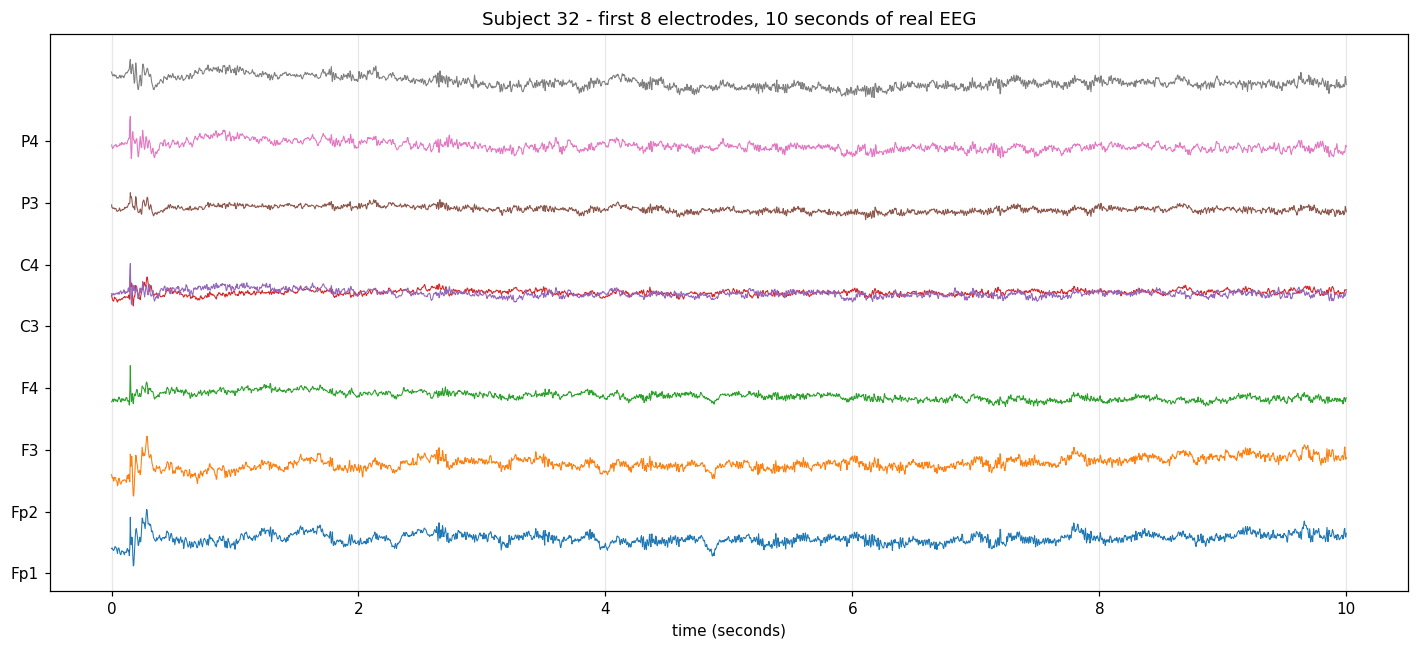

Each wiggly line is one electrode. Every wiggle is the summed electrical
activity of millions of neurons underneath that patch of scalp.


In [36]:
plt.figure(figsize=(13, 6))

# Draw all 8 channels on one plot, each shifted upward so they do not overlap.
for i in range(8):
    # * 1e6 converts volts to microvolts.
    # + i*150 pushes each channel up by 150 microvolts so they stack neatly.
    # This offset is for DISPLAY ONLY - it does not change the data.
    plt.plot(times, volts[i] * 1e6 + i * 150, lw=0.7)

# Label the y-axis with channel names at the height of each trace.
plt.yticks(np.arange(8) * 150, raw.ch_names[:8])
plt.xlabel("time (seconds)")
plt.title(f"Subject {subject} - first 8 electrodes, 10 seconds of real EEG")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("Each wiggly line is one electrode. Every wiggle is the summed electrical")
print("activity of millions of neurons underneath that patch of scalp.")

## Step 12 - Zoom in on two seconds

Ten seconds is too compressed to see the individual oscillations. Let's zoom right in on one
channel.

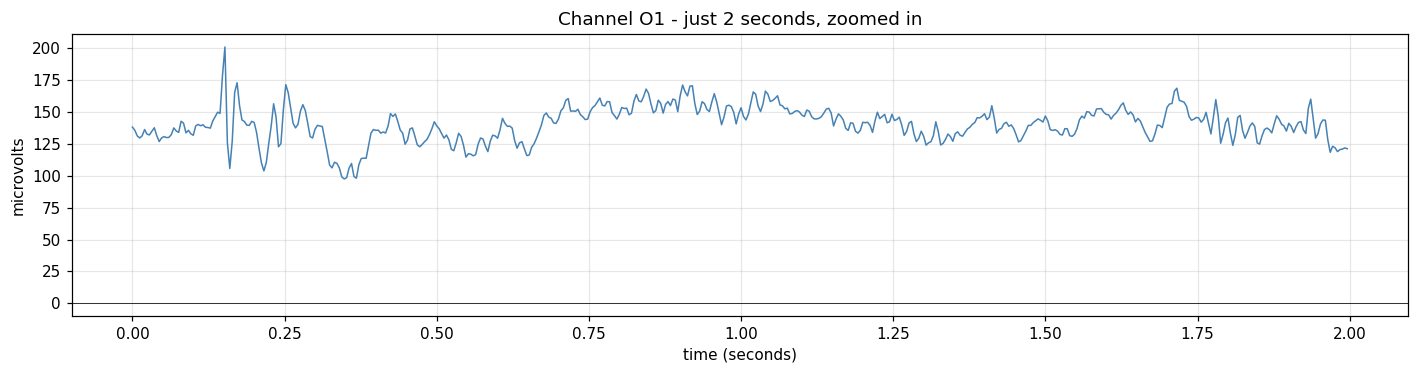

Range in this window : 97.5 to 200.9 microvolts

For scale: a torch battery is 1.5 volts. That is 1,500,000 microvolts.
You are looking at a signal roughly 20,000 times smaller than a battery,
measured through a skull.


In [37]:
channel_index = 8   # channel 8 is O1 - left occipital, at the back of the head

# Get one channel's full 10 seconds.
one_channel, t = segment[channel_index, :]
one_channel = one_channel.ravel() * 1e6   # flatten to 1D and convert to microvolts

# Keep only the first 2 seconds. int(...) because array positions must be whole numbers.
n_keep = int(2 * sampling_rate)

plt.figure(figsize=(13, 3.5))
plt.plot(t[:n_keep], one_channel[:n_keep], lw=1, color="steelblue")
plt.axhline(0, color="black", lw=0.5)
plt.xlabel("time (seconds)")
plt.ylabel("microvolts")
plt.title(f"Channel {raw.ch_names[channel_index]} - just 2 seconds, zoomed in")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Range in this window : {one_channel[:n_keep].min():.1f} to "
      f"{one_channel[:n_keep].max():.1f} microvolts")
print()
print("For scale: a torch battery is 1.5 volts. That is 1,500,000 microvolts.")
print("You are looking at a signal roughly 20,000 times smaller than a battery,")
print("measured through a skull.")

Now you can see the oscillation. EEG is not random noise - it has rhythm. The brain produces
several overlapping rhythms at once, and they have standard names:

| band | frequency | loosely associated with |
|---|---|---|
| delta | 0.5 - 4 Hz | deep sleep |
| theta | 4 - 8 Hz | drowsiness, memory |
| **alpha** | **8 - 12 Hz** | **relaxed wakefulness, strongest at the back of the head** |
| beta | 12 - 30 Hz | active concentration |
| gamma | 30 Hz and up | fine-grained processing |

Part 4 is entirely about separating a signal into these bands. For now, just register that the
wiggle is made of several rhythms layered on top of each other.

## Step 13 - Check the rhythms are really there

A **power spectrum** answers "how much of each frequency is in this signal?". MNE will compute one
for us. This is a preview of Part 4, not the full story.

c:\Users\test\anaconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


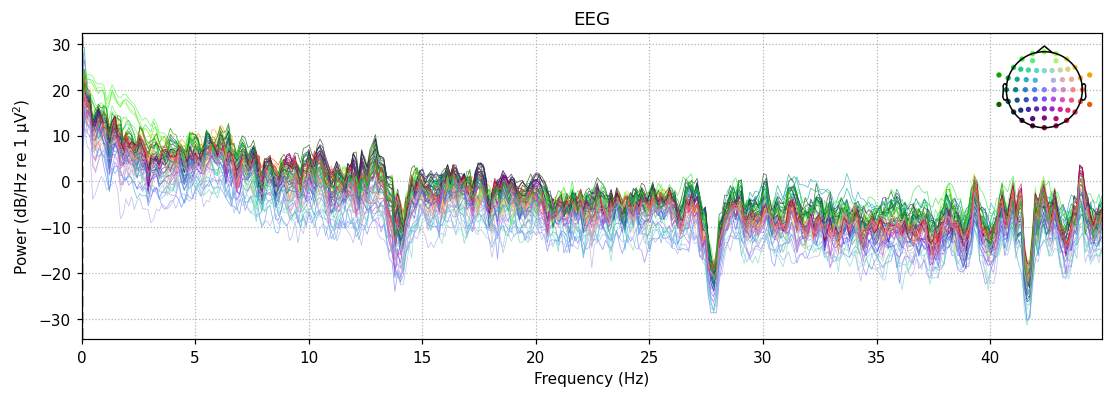

Each thin line is one electrode. Two things to look for:

  1. The overall downward slope. Low frequencies always carry more
     power than high ones in EEG. This is called the 1/f slope and
     it is universal in brain signals.

  2. A bump somewhere around 8-12 Hz. That is the alpha rhythm.
     It should be clearest on the occipital channels (O1, O2, Oz)
     at the back of the head.


In [38]:
# Load 60 seconds this time - frequency estimates need a decent chunk of data.
minute = raw.copy().crop(0, 60).load_data()

# compute_psd = power spectral density. fmax=45 limits the plot to 0-45 Hz.
psd = minute.compute_psd(fmax=45)

psd.plot(picks="all", amplitude=False, show=True)
plt.show()

print("Each thin line is one electrode. Two things to look for:")
print()
print("  1. The overall downward slope. Low frequencies always carry more")
print("     power than high ones in EEG. This is called the 1/f slope and")
print("     it is universal in brain signals.")
print()
print("  2. A bump somewhere around 8-12 Hz. That is the alpha rhythm.")
print("     It should be clearest on the occipital channels (O1, O2, Oz)")
print("     at the back of the head.")

If you can see a 1/f slope and an alpha bump, the artifact correction did its job. A recording
still full of gradient artifact would be dominated by sharp spikes at the scanner's switching
frequency and its multiples, drowning everything else.

This is a quick, useful sanity check you can run on any EEG dataset.

## Step 14 - The EEG runs longer than the scan

One last thing, and it is easy to miss.

In [39]:
eeg_duration  = raw.n_times / raw.info["sfreq"]
fmri_duration = 300 * TR   # 300 volumes from Part 1

print(f"EEG recording  : {eeg_duration:.1f} seconds")
print(f"fMRI scan      : {fmri_duration:.1f} seconds")
print(f"Difference     : {eeg_duration - fmri_duration:.1f} seconds of extra EEG")
print()

surplus = eeg_duration - fmri_duration

# Different subjects have very different amounts of surplus, so comment accordingly.
if surplus > 30:
    print("There is a lot of extra EEG. The recording was clearly started well")
    print("before the scan and stopped well after - standard practice, so you")
    print("are certain to capture the whole scan.")
elif surplus > -5:
    print("The two are almost the same length. For this subject the EEG was")
    print("started and stopped very close to the scan itself.")
else:
    print("The EEG is SHORTER than the scan. Check this subject carefully -")
    print("some volumes may have no EEG to pair with.")

print()
print("Either way, the pipeline only ever consumes the first 294 windows,")
print("counting from EEG sample 0. Any surplus at the end is discarded, and")
print("the two streams are assumed to be aligned at their START.")

EEG recording  : 648.1 seconds
fMRI scan      : 648.0 seconds
Difference     : 0.1 seconds of extra EEG

The two are almost the same length. For this subject the EEG was
started and stopped very close to the scan itself.

Either way, the pipeline only ever consumes the first 294 windows,
counting from EEG sample 0. Any surplus at the end is discarded, and
the two streams are assumed to be aligned at their START.


### What this quietly assumes

The pipeline lines up EEG sample 0 with fMRI volume 0 and trusts that they began together. The
dataset's documentation says the EEG and MRI clocks were synchronised, so this is a reasonable
assumption here.

But note that the `.vmrk` marker file contains the actual timestamps of every scanner volume. A
more careful pipeline would use those markers to find exactly where the scan began inside the EEG
recording, rather than assuming it was at sample zero. This one does not.

If you ever want to extend the project, that is a real and defensible improvement to investigate.

Subject-by-subject, this varies: subject 35's EEG runs 789 seconds against a 648 second scan, but
subject 32's runs 648 seconds - almost exactly the scan length. Different lengths mean the
recordings were started at different offsets, which is exactly the situation markers exist to
resolve.

## Step 15 - What you now know

| thing | value | why it matters |
|---|---|---|
| format | 3 files: `.vhdr` + `.vmrk` + `.dat` | all three must sit together |
| use | `export/`, never `raw/` | `raw/` is buried under scanner artifact |
| sampling rate | **250 Hz**, not 5000 | 540 samples per fMRI volume, not 10,800 |
| channels | 64 | but one of them is `ECG`, not a brain electrode |
| units | microvolts | ~20,000x smaller than a torch battery |
| header filenames | wrong (spaces vs underscores) | your data folder must be writable |
| duration | often longer than the scan | streams assumed aligned at the start |

The idea to carry into Part 4:

**Raw EEG is a wiggly line, but the model does not eat wiggly lines.** It eats pictures. Part 4 is
about the transformation that turns 540 voltage samples into a picture of which frequencies were
present - and that picture is what actually enters the network.

---

### Try these before moving on

1. In Step 10, change `[:8, :]` to `[8:16, :]` to see a different set of electrodes. Do the occipital ones (O1, O2) look different from the frontal ones (Fp1, Fp2)?
2. In Step 11, set `channel_index = 0` (Fp1, right above the eye). You should see large slow swings that the occipital channel does not have. Those are **eye blinks** - the eyeball is electrically charged, so moving it creates voltage at nearby electrodes.
3. In Step 11, change the 2 second window to 0.5 seconds. Can you count individual alpha cycles?
4. In Step 4, change `export_files[0]` to `export_files[1]` and re-run everything. Does the second subject have the same sampling rate and channel count?

Number 2 is the most instructive. Eye blinks are a textbook EEG artifact and being able to
recognise them on sight is a genuinely useful skill.

---

### Coming next

**Part 4 - From waves to pictures.** The Fourier transform, in plain language: how you take 540
voltage samples and work out which frequencies they are made of. Then we build the repo's own
custom spectrogram function step by step and see the image the model actually receives.

Tell me when you are ready.

<br><br>

---
---

<br>

# Part 4 - From waves to pictures

Part 3 ended with a wiggly line. The model does not eat wiggly lines.

It eats **pictures**: 2D grids of numbers, like the fMRI slices in Part 1. So there has to be a
step that turns 540 voltage samples into a picture. That step is this part.

**Goal of this part:** understand the Fourier transform well enough to rebuild the repo's own
spectrogram function line by line, and see the exact image the network receives.

---

### The one-sentence version

A **spectrogram** answers: *"at each moment, how much of each frequency was present?"* - and the
answer is naturally a picture, with time across the bottom and frequency up the side.

---

### Before you start

Part 4 continues from Part 3 in the same file. It reuses `raw`, `sampling_rate`, `subject` and
`TR`. If you restarted the kernel, re-run Part 3 from Step 1 first.

In [40]:
# Two new imports for this part.
from scipy.fft import fft          # the Fast Fourier Transform
from scipy.stats import zscore     # standardisation, used at the very end

# MNE warns "No coordinate information found for channels ['ECG']" every time it
# opens a file. We already know why (Part 3, Step 10) and we are about to open 16
# files in a loop, so silence it to keep the output readable.
import warnings
warnings.filterwarnings("ignore", message=".*coordinate information.*")
warnings.filterwarnings("ignore", message=".*misc channel.*")

# Check the Part 3 variables are still around.
try:
    raw
    print(f"Continuing with subject {subject}")
    print(f"Sampling rate : {raw.info['sfreq']} Hz")
    print(f"Channels      : {len(raw.ch_names)}")
except NameError:
    print("Part 3 variables are gone. Scroll up and re-run Part 3 from Step 1.")

Continuing with subject 32
Sampling rate : 250.0 Hz
Channels      : 64


## Step 1 - The problem the Fourier transform solves

Here is the whole idea, and it is simpler than its reputation.

Any wiggly line, however messy, can be rebuilt by **adding together plain sine waves** of
different frequencies, each with its own strength.

The Fourier transform runs that backwards. You give it the messy line, and it tells you which
sine waves were in the mix and how strong each one was.

An analogy that actually holds: a musical chord is one complicated pressure wave hitting your ear.
Your ear separates it into individual notes. The Fourier transform is that separation, done with
arithmetic.

The best way to believe this is to build a signal from known ingredients and then check that the
transform recovers them.

In [41]:
# Build a fake signal out of three sine waves whose frequencies WE choose.
# Then we will hand it to the Fourier transform and see if it finds them.

fs       = 250     # pretend sampling rate: 250 samples per second
duration = 2.0     # 2 seconds long

# np.linspace(start, stop, count) makes evenly spaced numbers.
# endpoint=False stops it including the final value, which keeps the spacing exact.
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# np.sin(2 * pi * frequency * time) is the standard formula for a sine wave.
# The number in front is the amplitude - how tall the wave is.
wave_10hz = 3.0 * np.sin(2 * np.pi * 10 * t)   # 10 Hz, amplitude 3   (alpha-like)
wave_25hz = 1.0 * np.sin(2 * np.pi * 25 * t)   # 25 Hz, amplitude 1   (beta-like)
wave_40hz = 0.5 * np.sin(2 * np.pi * 40 * t)   # 40 Hz, amplitude 0.5 (gamma-like)

# Add them together. This is our "messy" signal.
mixed = wave_10hz + wave_25hz + wave_40hz

print(f"Built a {duration} second signal with {len(mixed)} samples.")
print()
print("Ingredients (which we will pretend not to know in a moment):")
print("   10 Hz at strength 3.0")
print("   25 Hz at strength 1.0")
print("   40 Hz at strength 0.5")

Built a 2.0 second signal with 500 samples.

Ingredients (which we will pretend not to know in a moment):
   10 Hz at strength 3.0
   25 Hz at strength 1.0
   40 Hz at strength 0.5


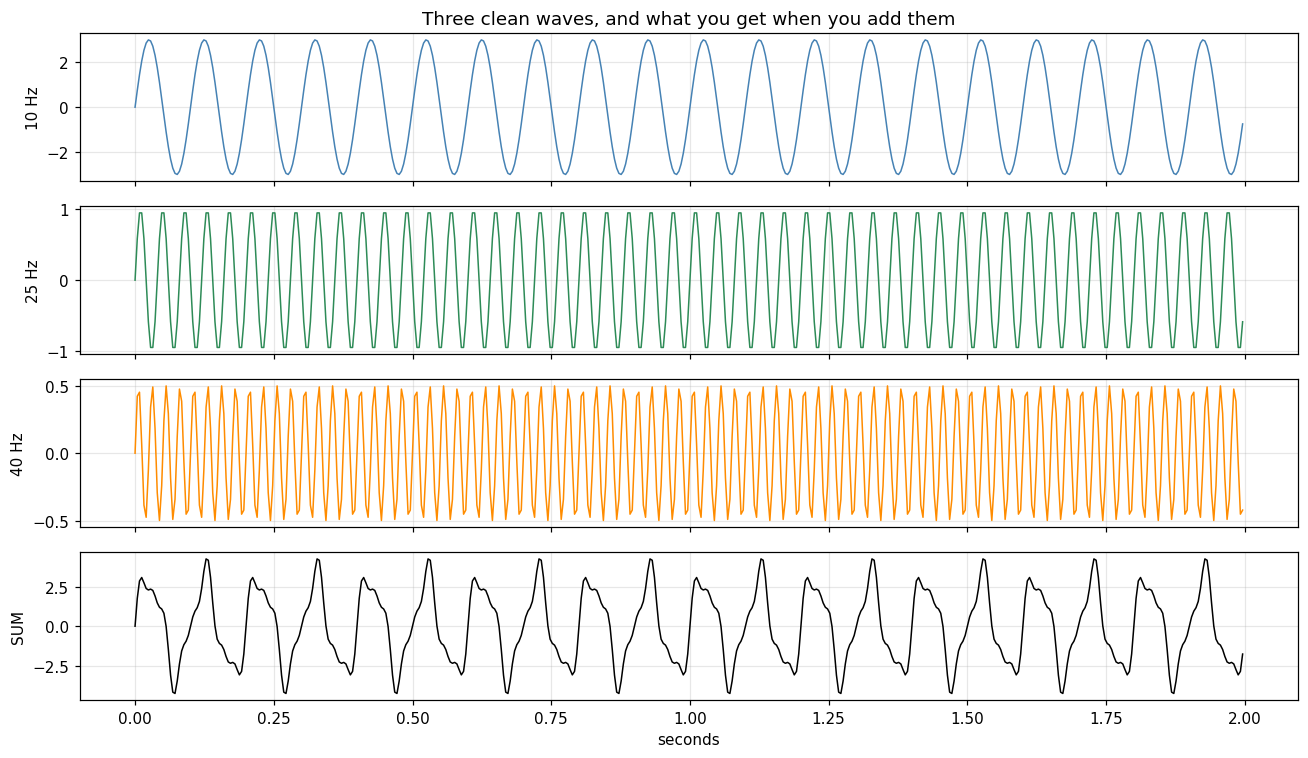

Look at the bottom line. Could you read off '10, 25 and 40 Hz' just by
staring at it? Neither can anyone else. That is the problem.


In [42]:
# Draw the ingredients and the mixture.
fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t, wave_10hz, lw=1, color="steelblue")
axes[0].set_ylabel("10 Hz")

axes[1].plot(t, wave_25hz, lw=1, color="seagreen")
axes[1].set_ylabel("25 Hz")

axes[2].plot(t, wave_40hz, lw=1, color="darkorange")
axes[2].set_ylabel("40 Hz")

axes[3].plot(t, mixed, lw=1, color="black")
axes[3].set_ylabel("SUM")
axes[3].set_xlabel("seconds")

axes[0].set_title("Three clean waves, and what you get when you add them")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Look at the bottom line. Could you read off '10, 25 and 40 Hz' just by")
print("staring at it? Neither can anyone else. That is the problem.")

## Step 2 - Hand the mixture to the Fourier transform

In [43]:
# fft() takes the signal and returns one complex number per frequency bin.
spectrum = fft(mixed)

print("Input  length:", len(mixed))
print("Output length:", len(spectrum), " <- same count, but they are now FREQUENCIES not times")
print()
print("First 3 output values:", np.round(spectrum[:3], 2))
print()
print("Those are COMPLEX numbers - they have a real part and an imaginary part.")
print("Each one packs two facts about its frequency:")
print("   how STRONG that frequency is  -> the size of the number")
print("   WHERE in its cycle it started -> the direction of the number (its phase)")
print()
print("For our purposes we only want strength, so we take the size with np.abs().")

Input  length: 500
Output length: 500  <- same count, but they are now FREQUENCIES not times

First 3 output values: [ 0.-0.j -0.-0.j  0.+0.j]

Those are COMPLEX numbers - they have a real part and an imaginary part.
Each one packs two facts about its frequency:
   how STRONG that frequency is  -> the size of the number
   WHERE in its cycle it started -> the direction of the number (its phase)

For our purposes we only want strength, so we take the size with np.abs().


Bin spacing: 250 Hz / 500 samples = 0.500 Hz per bin



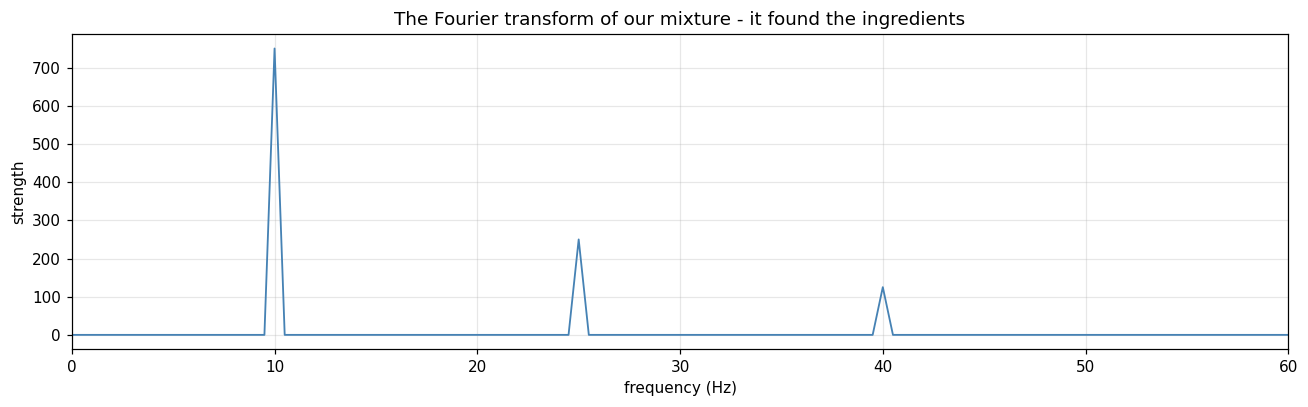

The three strongest frequencies found:
    10.0 Hz   (strength 750)
    25.0 Hz   (strength 250)
    40.0 Hz   (strength 125)


In [44]:
# np.abs() on a complex number gives its magnitude - the strength of that frequency.
strength = np.abs(spectrum)

# Work out which real-world frequency each bin corresponds to.
# Bin spacing = sampling rate divided by number of samples.
bin_spacing = fs / len(mixed)
frequencies = np.arange(len(mixed)) * bin_spacing

print(f"Bin spacing: {fs} Hz / {len(mixed)} samples = {bin_spacing:.3f} Hz per bin")
print()

# Only the first half is meaningful (Step 4 explains why). Plot up to 60 Hz.
half = len(mixed) // 2

plt.figure(figsize=(12, 3.8))
plt.plot(frequencies[:half], strength[:half], lw=1.2, color="steelblue")
plt.xlim(0, 60)
plt.xlabel("frequency (Hz)")
plt.ylabel("strength")
plt.title("The Fourier transform of our mixture - it found the ingredients")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print the biggest peaks to confirm numerically, not just visually.
# np.argsort sorts and returns POSITIONS; [::-1] reverses to get largest first.
top = np.argsort(strength[:half])[::-1][:3]
print("The three strongest frequencies found:")
for pos in sorted(top):
    print(f"   {frequencies[pos]:5.1f} Hz   (strength {strength[pos]:.0f})")

Three spikes, at exactly 10, 25 and 40 Hz. And their relative heights are 3 : 1 : 0.5, matching
the amplitudes we chose.

The transform recovered our ingredients from the mixture without being told anything. That is the
whole trick, and it is why every EEG analysis in existence uses it.

## Step 3 - Bin spacing, and the resolution trade-off

Notice we did not get a continuous curve. We got values at fixed steps, and the step size came out
of one formula:

```
bin spacing (Hz) = sampling rate / number of samples
```

For our test: 250 / 500 = 0.5 Hz.

This is a genuine trade-off, not an implementation detail:

- **A longer window** gives finer frequency detail (smaller bin spacing), but blurs *when* things
  happened, because you averaged over a longer stretch of time.
- **A shorter window** pins down timing better, but frequency detail gets coarse.

You cannot have both. This is a real mathematical limit, not a software limitation.

Let's compute what the repo's actual choice gives.

In [45]:
# The repo uses a window of exactly one TR: 2.160 seconds at 250 Hz.
window_seconds = TR                              # 2.160
window_samples = int(window_seconds * sampling_rate)

print(f"Window length : {window_seconds} s x {sampling_rate:.0f} Hz = {window_samples} samples")
print()

repo_bin_spacing = sampling_rate / window_samples
print(f"Bin spacing   : {sampling_rate:.0f} / {window_samples} = {repo_bin_spacing:.4f} Hz per bin")
print()
print("So neighbouring frequency bins are about half a hertz apart.")
print("Fine enough to separate 10 Hz alpha from 12 Hz alpha. Good enough here.")

Window length : 2.16 s x 250 Hz = 540 samples

Bin spacing   : 250 / 540 = 0.4630 Hz per bin

So neighbouring frequency bins are about half a hertz apart.
Fine enough to separate 10 Hz alpha from 12 Hz alpha. Good enough here.


### Why the window is exactly one TR

This is a deliberate and rather elegant choice:

```python
'f_resample': 2.160,   # data_cfg.py - and it is ALSO the fMRI TR
```

and in `utils.py`, `stft` is called with `window_size=f_resample`.

Because the window equals the TR, **each spectrogram column lines up with exactly one fMRI
volume.** No interpolation, no resampling, no fiddly alignment. EEG window 0 covers the same 2.16
seconds as volume 0, window 1 matches volume 1, and so on all the way down.

Everything downstream is simple pairing because of this one decision.

## Step 4 - Nyquist, and why only half the output is real

Our FFT of 500 samples gave 500 outputs, but we only plotted the first 250. Here is why.

There is a hard ceiling on what any sampled signal can represent, called the **Nyquist limit**:

```
highest meaningful frequency = sampling rate / 2
```

The intuition: to record a wave you need at least two samples per cycle, one for the peak and one
for the trough. Any faster wiggle slips between your samples and cannot be reconstructed.

At 250 Hz, the ceiling is **125 Hz**. Everything the FFT reports above that is a mathematical
mirror image of what is below it, and carries no new information.

In [46]:
nyquist = sampling_rate / 2
print(f"Sampling rate : {sampling_rate:.0f} Hz")
print(f"Nyquist limit : {nyquist:.0f} Hz  <- nothing above this is real")
print()

# Which bin number corresponds to the Nyquist limit?
nyquist_bin = window_samples // 2
print(f"Bin at Nyquist: {nyquist_bin}  (of {window_samples} total bins)")
print()
print("Bin -> frequency, for a few landmarks:")
for b in [0, 1, 10, 22, 65, 249, 250, 270, 400]:
    hz = b * repo_bin_spacing
    note = ""
    if b == 0:            note = "  <- the DC / average-offset bin"
    elif b == 250:        note = "  <- where the repo cuts"
    elif b == nyquist_bin: note = "  <- Nyquist. Above here is mirror image."
    elif b > nyquist_bin: note = "  <- MIRROR, no new information"
    print(f"   bin {b:>3}  =  {hz:6.1f} Hz{note}")

Sampling rate : 250 Hz
Nyquist limit : 125 Hz  <- nothing above this is real

Bin at Nyquist: 270  (of 540 total bins)

Bin -> frequency, for a few landmarks:
   bin   0  =     0.0 Hz  <- the DC / average-offset bin
   bin   1  =     0.5 Hz
   bin  10  =     4.6 Hz
   bin  22  =    10.2 Hz
   bin  65  =    30.1 Hz
   bin 249  =   115.3 Hz
   bin 250  =   115.7 Hz  <- where the repo cuts
   bin 270  =   125.0 Hz  <- Nyquist. Above here is mirror image.
   bin 400  =   185.2 Hz  <- MIRROR, no new information


## Step 5 - The repo's `compute_fft`, line by line

Now we can read the repo's actual code and understand every part of it. From `utils.py`:

```python
def compute_fft(signal_1d, limit=True, f_limit=250):
    N = len(signal_1d)
    fft1 = fft(signal_1d)

    if limit:
        if fft1.shape[0] > f_limit:
            return fft1[:f_limit]
        ...
    return np.abs(fft1[:N//2])
```

Three things to notice, one of which is a genuine trap.

In [47]:
def compute_fft_repo(signal_1d, limit=True, f_limit=250):
    """An exact copy of the repo's compute_fft, with comments added."""

    N = len(signal_1d)

    # Transform the window into frequency bins. Still COMPLEX at this point.
    fft1 = fft(signal_1d)

    if limit:
        # Keep only the first f_limit bins and throw the rest away.
        # NOTE: it returns them still complex - abs() happens later, in stft().
        if fft1.shape[0] > f_limit:
            return fft1[:f_limit]
        # If the signal was shorter than f_limit, pad with zeros instead.
        return np.append(fft1, np.zeros((f_limit - fft1.shape[0],), dtype=np.complex128))

    # The unlimited path takes the magnitude and keeps only the meaningful half.
    return np.abs(fft1[:N // 2])


# Try it on one real window of EEG.
# 300 seconds gives ~138 windows, wide enough to see structure over time.
segment_for_fft = raw.copy().crop(0, 300).load_data()
channel_data, _ = segment_for_fft[8, :]                # channel 8 = O1, occipital
channel_data = channel_data.ravel()                    # flatten to a plain 1D list

one_window = channel_data[:window_samples]             # the first 540 samples
print("One window:", one_window.shape, "samples")

result = compute_fft_repo(one_window, limit=True, f_limit=250)
print("compute_fft returned:", result.shape, "values of type", result.dtype)
print()
print("Still complex. The magnitude is taken in stft(), not here.")

One window: (540,) samples
compute_fft returned: (250,) values of type complex128

Still complex. The magnitude is taken in stft(), not here.


### The trap: `f_limit=250` is a **bin count**, not 250 Hz

This one catches almost everyone, including people who have used the repo.

The parameter is named `f_limit` and set to `250`, and the sampling rate also happens to be
`250` Hz. It reads exactly like "keep everything up to 250 Hz".

It does not. Look at the code: `fft1[:f_limit]` slices by **position in the array**. It keeps the
first 250 **bins**. And a bin is 0.463 Hz wide.

In [48]:
f_limit = 250   # the value from data_cfg.py

print("If f_limit meant Hz  : we would keep 0 to 250 Hz")
print(f"What it ACTUALLY does : keeps bins 0 to {f_limit-1}")
print()
print(f"Bin {f_limit-1} sits at {(f_limit-1) * repo_bin_spacing:.1f} Hz")
print()
print(f"So the real retained band is 0 to about {(f_limit-1)*repo_bin_spacing:.0f} Hz,")
print(f"not 0 to 250 Hz. It is also comfortably under the {nyquist:.0f} Hz Nyquist")
print("limit, so nothing mirrored sneaks in - which is lucky, or possibly")
print("deliberate, but the code does not say which.")
print()
print("Practical effect: nothing. EEG has almost no usable power above 100 Hz,")
print("so cutting at 115 Hz throws away essentially nothing.")
print()
print("Why it still matters: if you write 'frequencies up to 250 Hz' in your")
print("report, that is wrong, and it is the kind of wrong a reviewer spots.")

If f_limit meant Hz  : we would keep 0 to 250 Hz
What it ACTUALLY does : keeps bins 0 to 249

Bin 249 sits at 115.3 Hz

So the real retained band is 0 to about 115 Hz,
not 0 to 250 Hz. It is also comfortably under the 125 Hz Nyquist
limit, so nothing mirrored sneaks in - which is lucky, or possibly
deliberate, but the code does not say which.

Practical effect: nothing. EEG has almost no usable power above 100 Hz,
so cutting at 115 Hz throws away essentially nothing.

Why it still matters: if you write 'frequencies up to 250 Hz' in your
report, that is wrong, and it is the kind of wrong a reviewer spots.


## Step 6 - The repo's `stft`, line by line

`compute_fft` handles one window. `stft` chops the whole recording into windows and runs
`compute_fft` on each.

The name is slightly misleading. This is **not** `scipy.signal.stft`. It is a hand-written version
with two differences that matter:

1. **No overlap.** Windows sit side by side, never sharing samples. Most standard STFT
   implementations overlap by 50% or more.
2. **No window function.** Standard practice multiplies each chunk by a taper (Hann, Hamming) to
   reduce edge effects. This does not.

Neither is wrong. Both follow from the design goal: one window per fMRI volume, exactly.

In [49]:
def stft_repo(signal, window_size=2.160, fs=250, f_limit=250):
    """The repo's stft, simplified to one channel and heavily commented."""

    # How many samples in one window.
    fs_window_size = int(window_size * fs)

    # The starting position of each window: 0, 540, 1080, 1620, ...
    # This is what makes them NON-overlapping - the step equals the window length.
    sample_range = list(range(0, len(signal), fs_window_size))

    # If the signal does not divide evenly, the final window would be short.
    # Drop it rather than analyse an incomplete chunk.
    if len(signal) % fs_window_size != 0:
        sample_range = sample_range[:-1]

    Z = []
    for start in sample_range:
        # Cut out this window.
        chunk = signal[start : start + fs_window_size]

        # Transform it (returns complex, truncated to f_limit bins).
        spec = compute_fft_repo(chunk, limit=True, f_limit=f_limit)

        # abs() -> strength. [1:] -> drop bin 0.
        # Bin 0 is the DC component: the window's average voltage offset.
        # In Part 3 we saw the signal sitting around +140 microvolts rather than
        # centred on zero. That offset is not brain activity, so it is discarded.
        Z.append(list(abs(spec[1:])))

    # np.transpose flips rows and columns, so we end up with
    # (frequency bins, time windows) - the conventional spectrogram layout.
    return np.transpose(np.array(Z))


spectrogram = stft_repo(channel_data, window_size=TR, fs=int(sampling_rate), f_limit=250)

print("Spectrogram shape:", spectrogram.shape)
print()
print(f"   {spectrogram.shape[0]} rows    = frequency bins (250 kept, minus bin 0 = 249)")
print(f"   {spectrogram.shape[1]} columns = time windows, one per fMRI volume")

Spectrogram shape: (249, 138)

   249 rows    = frequency bins (250 kept, minus bin 0 = 249)
   138 columns = time windows, one per fMRI volume


## Step 7 - Look at the picture

This is the moment the wiggly line becomes an image.

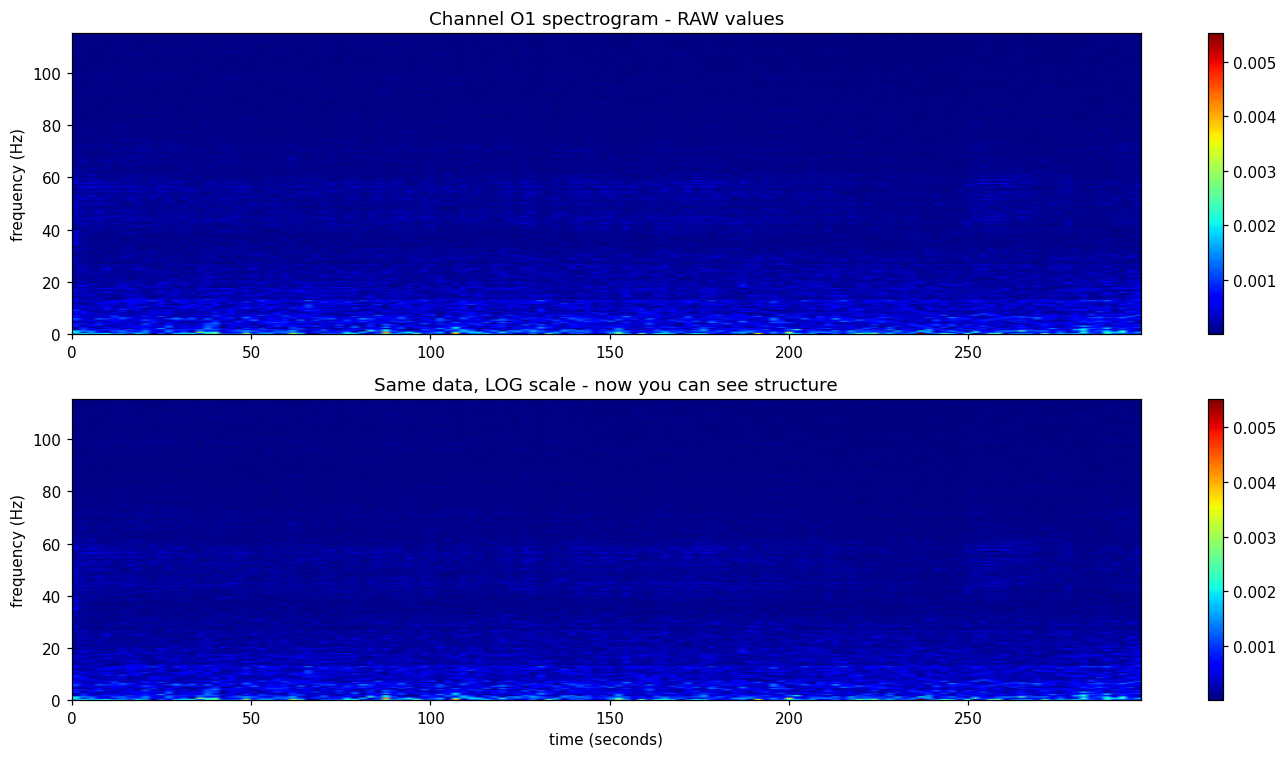

origin='lower' puts 0 Hz at the BOTTOM, which is the convention.
Without it, matplotlib would draw the picture upside down.


In [50]:
# Work out the real frequency of the top row, for labelling the axis.
max_hz = spectrogram.shape[0] * repo_bin_spacing

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Top: the raw values.
im0 = axes[0].imshow(spectrogram, aspect="auto", origin="lower", cmap="jet",
                     extent=[0, spectrogram.shape[1]*TR, 0, max_hz])
axes[0].set_ylabel("frequency (Hz)")
axes[0].set_title(f"Channel {raw.ch_names[8]} spectrogram - RAW values")
plt.colorbar(im0, ax=axes[0])

# Bottom: the same thing on a log scale.
# np.log1p(x) computes log(1+x). The +1 avoids log(0), which is undefined.
# Without this, the low frequencies are so much stronger that everything
# else looks uniformly black.
im1 = axes[1].imshow(np.log1p(spectrogram), aspect="auto", origin="lower", cmap="jet",
                     extent=[0, spectrogram.shape[1]*TR, 0, max_hz])
axes[1].set_ylabel("frequency (Hz)")
axes[1].set_xlabel("time (seconds)")
axes[1].set_title("Same data, LOG scale - now you can see structure")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print("origin='lower' puts 0 Hz at the BOTTOM, which is the convention.")
print("Without it, matplotlib would draw the picture upside down.")

Read the log version. Nearly all the energy is crammed into the bottom strip, below about 30
Hz. Above that it is close to empty.

That is not a mistake - it is the 1/f slope from Part 3, seen from a different angle. Brains put
far more power into slow rhythms than fast ones.

It also means the top two thirds of every input image the model receives is nearly blank. Worth
knowing when you think about what the encoder actually has to work with.

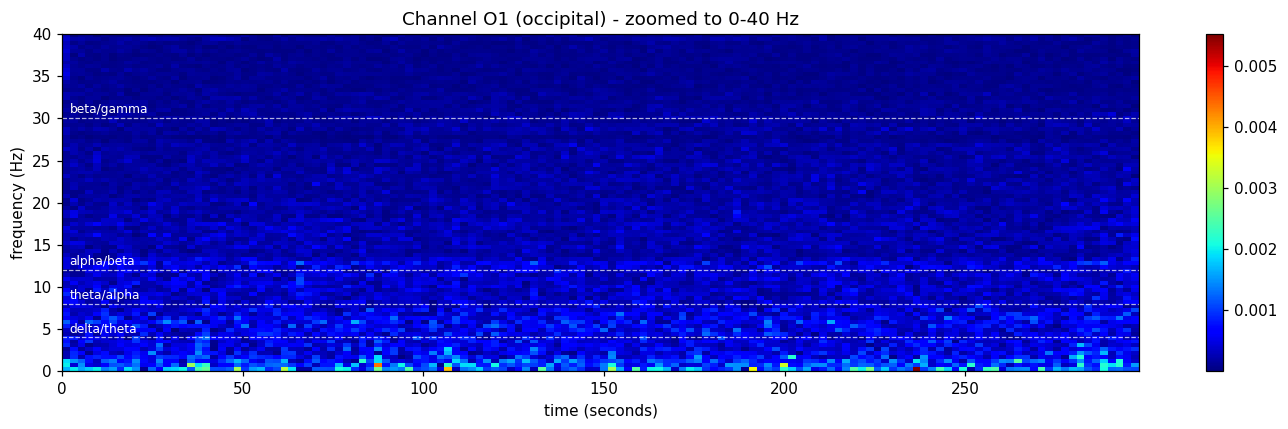

Look for a warm horizontal band around 8-12 Hz that comes and goes.
That is alpha rhythm waxing and waning as attention drifts - a real,
interpretable brain signal, visible by eye.


In [51]:
# Zoom into the bottom 40 Hz, where everything actually happens.
# How many bins is 40 Hz? Divide by the bin spacing and round to a whole number.
bins_to_40hz = int(40 / repo_bin_spacing)

plt.figure(figsize=(13, 4))
plt.imshow(np.log1p(spectrogram[:bins_to_40hz, :]), aspect="auto", origin="lower",
           cmap="jet", extent=[0, spectrogram.shape[1]*TR, 0, 40])

# Mark the classic EEG frequency bands from Part 3.
for hz, name in [(4, "delta/theta"), (8, "theta/alpha"), (12, "alpha/beta"), (30, "beta/gamma")]:
    plt.axhline(hz, color="white", ls="--", lw=0.8, alpha=0.7)
    plt.text(2, hz + 0.6, name, color="white", fontsize=8)

plt.ylabel("frequency (Hz)")
plt.xlabel("time (seconds)")
plt.title(f"Channel {raw.ch_names[8]} (occipital) - zoomed to 0-40 Hz")
plt.colorbar()
plt.tight_layout()
plt.show()

print("Look for a warm horizontal band around 8-12 Hz that comes and goes.")
print("That is alpha rhythm waxing and waning as attention drifts - a real,")
print("interpretable brain signal, visible by eye.")

## Step 8 - All 64 channels: the actual model input

So far, one channel. The repo loops over all 64:

```python
x_instance = []
for channel in range(len_channels):          # 0 to 63
    _, Zxx, _ = stft(eeg_data, channel=channel, ...)
    x_instance += [Zxx]
```

That builds a stack of 64 spectrograms.

This is also where the `ECG` channel from Part 3 gets swept in - the loop does not check what kind
of channel it is.

In [52]:
# Running all 64 channels over the full recording takes a while, so we use
# a 60 second excerpt to demonstrate. The shape logic is identical.
excerpt = raw.copy().crop(0, 60).load_data()
all_channels, _ = excerpt[:, :]     # shape (64, n_samples)

print("Loaded", all_channels.shape, "= (channels, samples)")
print("Computing 64 spectrograms...")

# A list comprehension over all 64 channels.
stack = np.array([stft_repo(all_channels[ch], window_size=TR,
                            fs=int(sampling_rate), f_limit=250)
                  for ch in range(all_channels.shape[0])])

print()
print("Stack shape:", stack.shape)
print(f"   {stack.shape[0]} = channels")
print(f"   {stack.shape[1]} = frequency bins")
print(f"   {stack.shape[2]} = time windows in this 60 second excerpt")

Loaded (64, 15001) = (channels, samples)
Computing 64 spectrograms...

Stack shape: (64, 249, 27)
   64 = channels
   249 = frequency bins
   27 = time windows in this 60 second excerpt


### The single most important slice

Take one time window out of that stack. Fix the time, keep all channels and all frequencies.

You get a **64 x 249** grid: for one 2.16 second moment, how much of each frequency was at each
electrode.

**That grid is one unit of what the model sees.** Everything else in the encoder is built to read
images of this shape.

One moment: (64, 249) = (64 channels, 249 frequency bins)



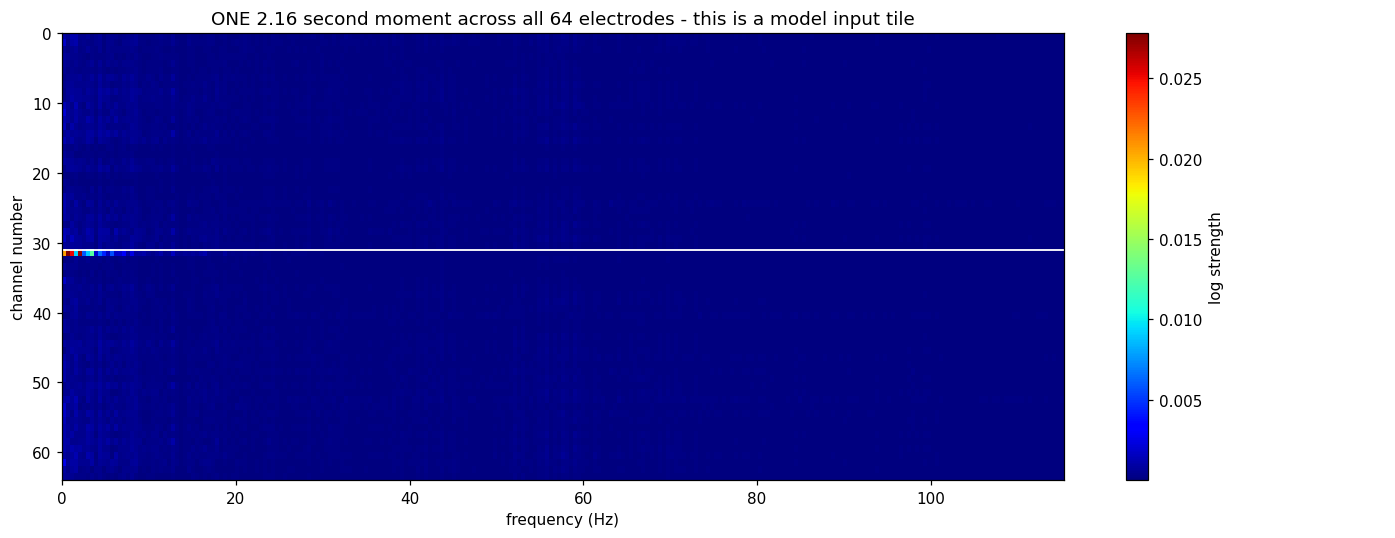

Vertical stripes = a frequency present across many electrodes at once.
Horizontal stripes = one electrode behaving unlike its neighbours,
which usually means a bad contact or, for row 31, a different organ.


In [53]:
# stack[:, :, t] -> all channels, all frequencies, one time window.
one_moment = stack[:, :, 10]

print("One moment:", one_moment.shape, "= (64 channels, 249 frequency bins)")
print()

plt.figure(figsize=(13, 5))
plt.imshow(np.log1p(one_moment), aspect="auto", cmap="jet",
           extent=[0, 249 * repo_bin_spacing, 64, 0])   # 64 at top so channel 0 is first
plt.xlabel("frequency (Hz)")
plt.ylabel("channel number")
plt.title("ONE 2.16 second moment across all 64 electrodes - this is a model input tile")
plt.colorbar(label="log strength")

# Mark where the ECG channel sits, so you can see it is not like the others.
plt.axhline(31, color="white", lw=1.2)
plt.text(120, 30.5, "channel 31 = ECG (heartbeat, not brain)", color="white", fontsize=9)

plt.tight_layout()
plt.show()

print("Vertical stripes = a frequency present across many electrodes at once.")
print("Horizontal stripes = one electrode behaving unlike its neighbours,")
print("which usually means a bad contact or, for row 31, a different organ.")

## Step 9 - Standardisation, and a detail worth catching

The last step in `get_data_NODDI`:

```python
if standardize_eeg:
    eeg_data = zscore(np.array(x_instance))
```

A **z-score** rescales numbers so they have an average of 0 and a spread of 1:

```
z = (value - average) / spread
```

Neural networks train far better on inputs scaled like this. Raw spectrogram values range from
near zero to thousands, and that spread makes gradients behave badly.

The detail: **which direction does it average over?**

In [54]:
# scipy's zscore defaults to axis=0 - the FIRST dimension.
# Our stack is (channels, frequencies, time), so axis 0 is CHANNELS.

standardised = zscore(stack)

# The raw values are in VOLTS, so they are around 0.00001 - printing them with
# one decimal place would just show "0.0". :.2e means scientific notation.
print("Before:", stack.shape, f"range {stack.min():.2e} to {stack.max():.2e}")
print("After :", standardised.shape, f"range {standardised.min():.2f} to {standardised.max():.2f}")
print()
print("Look at the 'before' numbers: they are tiny, because MNE works in volts.")
print("After z-scoring they sit in a sensible range around zero, which is exactly")
print("what a neural network wants.")
print()

# Check the direction by measuring along each axis.
# If the average along an axis is ~0 and the spread is ~1, that is the axis used.
for axis, label in [(0, "channels"), (1, "frequencies"), (2, "time")]:
    m = np.abs(standardised.mean(axis=axis)).max()
    s = standardised.std(axis=axis).mean()
    marker = "  <-- THIS is the axis zscore used" if m < 1e-6 else ""
    print(f"along {label:<12}: mean {m:.6f}, spread {s:.4f}{marker}")

Before: (64, 249, 27) range 5.97e-08 to 4.15e-02
After : (64, 249, 27) range -3.14 to 7.93

Look at the 'before' numbers: they are tiny, because MNE works in volts.
After z-scoring they sit in a sensible range around zero, which is exactly
what a neural network wants.

along channels    : mean 0.000000, spread 1.0000  <-- THIS is the axis zscore used
along frequencies : mean 6.031664, spread 0.7368
along time        : mean 7.896291, spread 0.6751


### What that actually means

The normalisation runs **across the 64 channels**, separately for every (frequency, time) cell.

So for one frequency at one moment, the 64 electrode values are rescaled relative to *each other*.
The question the model gets asked is not "how strong was 10 Hz?" but **"which electrodes had more
10 Hz than the others, right now?"**

Consequences worth understanding:

- **Absolute power is erased.** A moment where the whole head had strong alpha looks the same as a
  moment where it was weak, provided the spatial pattern is similar.
- **The spatial pattern is everything.** This is arguably a sensible choice for source
  localisation, since where activity is matters more than gross amplitude.
- **The `ECG` channel is now inside the normalisation.** Its values contribute to the mean and
  spread that all 63 real electrodes are scaled against. A heartbeat spike nudges every other
  channel's normalised value at that instant.

That last point is the strongest argument for running the no-ECG ablation, if you have time. It is
not just one odd channel sitting quietly in the corner - it participates in scaling everything
else.

Whether `axis=0` was intended or is simply scipy's default left unchanged, the code does not say.
Either way, it is what your model is trained on, so describe it accurately.

## Step 10 - Do we have enough windows?

One last check, and it is tighter than you would expect.

The pipeline needs 300 windows per subject: 294 to keep, plus the 6 dropped by `bold_shift`. How
many does each subject actually produce?

In [55]:
print(f"{'subject':<10}{'samples':>10}{'windows':>10}{'needed':>9}   status")
print("=" * 58)

needed = 300   # n_volumes (294) + bold_shift (6)

for p in export_files:
    subj = p.parent.parent.name

    # Open just the header - fast, no voltage loading.
    r = mne.io.read_raw_brainvision(p, preload=False, verbose=0)
    n = r.n_times

    # Replicate the repo's window counting exactly.
    starts = list(range(0, n, window_samples))
    if n % window_samples != 0:
        starts = starts[:-1]          # drop the incomplete final window
    n_windows = len(starts)

    if n_windows > needed:
        status = f"fine ({n_windows - needed} spare)"
    elif n_windows == needed:
        status = "EXACTLY enough - zero margin"
    else:
        status = f"SHORT by {needed - n_windows}"

    print(f"{subj:<10}{n:>10,}{n_windows:>10}{needed:>9}   {status}")

subject      samples   windows   needed   status
32           162,023       300      300   EXACTLY enough - zero margin
35           197,235       365      300   fine (65 spare)
36           181,950       336      300   fine (36 spare)
37           195,160       361      300   fine (61 spare)
38           179,385       332      300   fine (32 spare)
39           182,130       337      300   fine (37 spare)
40           173,915       322      300   fine (22 spare)
42           184,910       342      300   fine (42 spare)
43           170,595       315      300   fine (15 spare)
44           169,855       314      300   fine (14 spare)
45           168,100       311      300   fine (11 spare)
46           172,265       319      300   fine (19 spare)
47           182,595       338      300   fine (38 spare)
48           171,740       318      300   fine (18 spare)
49           167,580       310      300   fine (10 spare)
50           168,020       311      300   fine (11 spare)


If any subject reports **SHORT**, that is a real problem. `get_data_NODDI` slices
`eeg_data[bold_shift : recording_time + bold_shift]`, and Python slicing past the end of an array
does **not** raise an error - it quietly returns fewer rows. You would get a subject with fewer
pairs and no warning at all.

Subject 32 is worth a second look: it produces **exactly 300** windows, with nothing to spare. Its
EEG recording is almost precisely the length of the scan. It works, but there is no margin
whatsoever. Had the recording stopped two seconds earlier, that subject would have silently lost a
window.

This is the kind of thing worth checking yourself rather than assuming, which is exactly why this
cell exists.

## Step 11 - What you now know

| thing | value | why it matters |
|---|---|---|
| what the FFT does | splits a signal into its sine-wave ingredients | turns a wave into a picture |
| window length | 2.160 s = 540 samples | deliberately equals one fMRI TR |
| bin spacing | 0.463 Hz | fine enough to separate alpha from beta |
| Nyquist limit | 125 Hz | nothing above this is real |
| `f_limit=250` | **bins**, not Hz | the real band is 0 to ~115 Hz |
| bin 0 dropped | the DC offset | not brain activity |
| bins kept | **249** | the width of every input tile |
| windows | non-overlapping, no taper | one window per volume, exactly |
| one input tile | **64 x 249** | channels by frequency, for one 2.16 s moment |
| standardisation | z-score **across channels** | the model sees spatial pattern, not absolute power |

The two ideas to carry into Part 5:

1. **One EEG "moment" is a 64 x 249 picture.** That is the atom the model works with.
2. **One window equals one volume, by design.** Which makes the final pairing step almost trivial
   arithmetic - and that is exactly what Part 5 is about.

---

### Try these before moving on

1. In Step 1, change `wave_10hz` to 7 Hz and re-run Steps 1 and 2. Does the peak move to 7 Hz?
2. In Step 1, add a fourth wave at 60 Hz with amplitude 2, add it into `mixed`, and re-run. Four peaks?
3. In Step 1, set `duration = 0.5` and re-run. The bin spacing gets four times coarser. Can you still separate 25 Hz from 40 Hz? This is the resolution trade-off from Step 3, felt rather than read.
4. In Step 7, change the channel from `8` (occipital) to `0` (frontal). Frontal channels usually show much less alpha but more low-frequency energy from eye movement. Can you see the difference?
5. In Step 9, try `zscore(stack, axis=2)` instead and compare the printed ranges. That would normalise across time rather than channels - a different model entirely.

---

### Coming next

**Part 5 - Putting them together.** The last piece: how 300 volumes and 365 EEG windows become 274
training pairs, why the model gets 20 TRs of EEG history for each single volume, what the `.h5`
files contain, and how to verify your processed dataset is correct before you train anything.

Tell me when you are ready and I will append it here.